# 학생 코호트의 중퇴까지 시간 생존분석

## 요약

**배경.** 4년제 대학의 기관연구실은 학생들이 *언제* 떠나는지, 단지 떠나는지 여부만이 아니라 그 시점을 이해하고자 합니다. 신입 코호트를 입학 시점부터 학기별로 추적합니다. 일부는 졸업하고, 일부는 중퇴하며, 관측 기간이 끝날 때까지 여전히 재학 중인 학생도 소수 있습니다. 여전히 재학 중인 학생의 결과는 알 수 없고(우측 절단), 졸업은 중퇴가 아니면서도 학생을 위험군에서 제거하기 때문에, 일반적인 합격/불합격 회귀는 타이밍 정보를 버리고 절단을 무시하는 어떤 추정치든 편향시킵니다. 올바른 도구는 **사건까지 시간(생존) 분석**이며, 관심 사건은 **중퇴**이고 시계는 재학한 학기 수로 측정됩니다.

**비즈니스 질문.** 학생의 **첫 학기 학사 상태**(조기 경보 플래그)가 코호트의 중퇴 타이밍 궤적을 분리하는가, 그리고 보정 후 중퇴 위험을 어떤 학생 특성이 좌우하는가? 답은 조기 경보 시스템에 반영됩니다: 추정 중퇴 위험이 높은 학생은 개입이 가장 저렴하고 효과적인 첫 학기에 상담 아웃리치를 받아야 합니다.

**접근법.** 우리는 100명 학생 코호트를 인라인으로 시뮬레이션한 뒤(외부 데이터 없음), 표준 생존 워크플로를 거칩니다:

1. **PROC MEANS**는 관측된 세 가지 결과(졸업 / 중퇴 / 여전히 재학) 전반에 걸쳐 예측변수들을 프로파일링하여 시뮬레이션된 신호가 타당하게 거동하는지 확인합니다.
2. **PROC FREQ**는 첫 학기 학사 상태를 결과와 교차표로 만들고 연관성에 대한 카이제곱 검정을 수행합니다.
3. **PROC UNIVARIATE**는 상태별 중퇴까지 시간의 강건한 백분위수를 보고합니다.
4. **PROC LIFETEST**는 상태별로 층화된 Kaplan-Meier 중퇴 곡선을 추정하고 **로그순위(log-rank)** 및 **Wilcoxon** 동일성 검정을 수행합니다.
5. **PROC PHREG**는 참조 코딩된 `CLASS` 효과, Efron 동점 처리, 위험한계 신뢰구간을 사용하여 중퇴 위험에 대한 다변량 **Cox 비례위험** 모델을 적합합니다.

**데이터가 보여주는 것.** 시뮬레이션된 100명 학생 중 **49명이 중퇴, 49명이 졸업, 2명이 12학기 시점에서 여전히 재학** 중이었습니다. 첫 학기에 **학사 경고**로 표시된 학생(첫 학기 GPA 2.5 미만)은 양호 상태의 학생보다 훨씬 빠르게 중퇴합니다: 중퇴까지 중앙값 시간 **3.8학기 대 8.7학기**로, 로그순위 검정이 확인하는 분리입니다(카이제곱 = 10.73, *p* = 0.0011). Cox 모델은 첫 학기 GPA(GPA 1점당 위험비 0.21, *p* < 0.0001), 고등학교 GPA(HR 0.45, *p* = 0.027), 1세대 대학생 지위(HR 2.03, *p* = 0.031)를 중퇴의 유의한 보정 동인으로 식별하며, GPA를 통제하면 Pell 보조금 지위는 유의하지 않습니다(HR 0.95, *p* = 0.85).

> *모든 수치는 예시이며 합성 데이터에서 생성되었습니다. 실제 학생 기록이 아닙니다. 이 환경은 라이선스 없이 실행되므로 코호트는 100명 학생 규모로 설정됩니다.*

## 데이터 출처

모든 데이터는 **합성**이며, 첫 DATA 스텝에서 `CALL STREAMINIT(20260611)`과 `RAND` 함수로 인라인 생성됩니다. 외부 파일이나 네트워크 접근이 없습니다. 시뮬레이션된 학생당 한 행입니다.

**데이터셋 `enrollments`** (100행, 학생당 한 행)

| 변수 | 유형 | 설명 | 생성 분포 |
|----------|------|-------------|--------------------------|
| `student_id` | Num | 고유 학생 키 | 순번 1–100 |
| `first_gen` / `first_gen_lbl` | Num / Char | 1세대 대학생 플래그(0/1)와 레이블 | 베르누이, ~42% |
| `pell` | Num | Pell 보조금(재정 필요) 플래그 (0/1) | 베르누이, ~42% |
| `program` | Char | STEM / BUS / HUM | 범주형 (~42% / 32% / 26%) |
| `hs_gpa` | Num | 고등학교 GPA (1.8–4.0) | Normal(3.00, 0.42), 절단 |
| `term1_gpa` | Num | 첫 학기 대학 GPA (0–4.0) | f(hs_gpa, program) + Normal 잡음 |
| `standing` | Char | 첫 학기 학사 상태 | `term1_gpa < 2.5` → 학사 경고, 그렇지 않으면 양호 상태 |
| `time_terms` | Num | 사건 또는 절단까지 재학한 학기 수 | 경쟁하는 Weibull 추출; 12에서 상한 |
| `dropped` | Num | 중퇴 사건 지시자 (1 = 중퇴, 0 = 절단) | 유도됨 |
| `outcome` | Char | 졸업 / 중퇴 / 재학 | 경쟁 추출로부터 유도됨 |

로그 척도의 잠재 선형예측자가 각 학생의 **중퇴율**을 첫 학기 GPA, 고등학교 GPA, 1세대 지위, 재정 필요와 연결하므로, 예측변수들은 진정하지만 잡음 있는 신호를 담습니다. 중퇴와 졸업은 **경쟁하는** 잠재 시간(Weibull)으로 추출되며, 12학기 창 안에서 먼저 발생하는 것이 관측 결과가 되고, 어느 것도 없이 12학기에 도달한 학생은 우측 절단됩니다. 생존 모델에서 **사건은 중퇴**(`dropped = 1`)이며, 졸업과 계속 재학은 모두 절단(`dropped = 0`)으로 처리됩니다.

## 1. 학생 코호트 시뮬레이션

첫 번째 셀은 100명 학생의 합성 코호트를 구축합니다. 로그 척도의 잠재 선형예측자가 각 학생의 중퇴율을 첫 학기 GPA, 고등학교 GPA, 1세대 지위, Pell 지위와 묶습니다. 중퇴와 졸업은 **경쟁하는** 잠재 시간(Weibull 추출)으로 생성되며, 12학기 관측 창 안에서 먼저 일어나는 것이 관측 결과가 되고, 중퇴하거나 졸업하지 않고 12학기에 도달한 학생은 우측 절단됩니다. 2.5 미만의 첫 학기 GPA는 학생을 **학사 경고**로 표시합니다 — 생존 단계에서 검정하는 조기 경보 신호입니다. 무작위 추출은 재현성을 위해 `CALL STREAMINIT`을 사용하고, 균등·정규·Weibull 분포 전반에 걸쳐 `RAND` 함수를 사용합니다. 하한과 클램프는 모든 값을 그럴듯하게 유지합니다(GPA는 0–4.0).

In [1]:
데이터 enrollments;
    호출 streaminit(20260611);
    길이 standing $30 first_gen_lbl $20 program $4 outcome $20;

    라벨 student_id    = "학생 식별자"
          first_gen     = "1세대 여부(플래그)"
          first_gen_lbl = "세대 구분"
          pell          = "펠 보조금 수혜(플래그)"
          program       = "전공 계열"
          hs_gpa        = "고교 내신(GPA)"
          term1_gpa     = "1학기 평점(GPA)"
          standing      = "학사 상태"
          time_terms    = "관측 학기 수"
          dropped        = "중도탈락 사건(1=탈락)"
          outcome       = "학적 결과";

    반복 student_id = 1 까지 100;
        /* 1세대 여부 및 재정지원 필요 플래그 */
        first_gen = (rand("uniform") < 0.42);
        만약 first_gen 이면 first_gen_lbl = "1세대";
        아니면              first_gen_lbl = "연속세대";
        pell = (rand("uniform") < 0.42);

        /* 전공 계열 (코드는 ASCII 유지) */
        v = rand("uniform");
        만약      v < 0.42 이면 program = "STEM";
        아니면 만약 v < 0.74 이면 program = "BUS";
        아니면                  program = "HUM";

        /* 학업 준비도 및 첫 학기 성취 */
        hs_gpa = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        term1_gpa = round(MIN(4.0, MAX(0.0,
                     0.55*hs_gpa + 1.05 + 0.12*(program="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* 조기 경보: 첫 학기 GPA 2.5 미만 = 학사 경고 */
        만약 term1_gpa < 2.5 이면 standing = "학사경고";
        아니면                    standing = "양호";

        /* 로그 척도의 잠재 중퇴 위험: 낮은 GPA, 1세대,
           펠 수혜가 중퇴율을 높인다. */
        eta = -1.05
             - 1.45*(term1_gpa - 2.8)
             - 0.55*(hs_gpa - 3.0)
             + 1.05*first_gen
             + 0.45*pell;
        drop_rate = EXP(eta);

        /* 경쟁 잠재 시간(학기): 중퇴 대 졸업 */
        t_drop = rand("weibull", 1.2, 7.0) / MAX(0.30, drop_rate);
        t_grad = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(term1_gpa - 2.8));

        /* 12학기 행정적 절단 창 */
        censor_at = 12;
        만약 t_drop <= t_grad 그리고 t_drop <= censor_at 이면 반복;
            outcome = "중퇴";   dropped = 1; time_terms = t_drop;
        종료;
        아니면 만약 t_grad < t_drop 그리고 t_grad <= censor_at 이면 반복;
            outcome = "졸업"; dropped = 0; time_terms = t_grad;
        종료;
        아니면 반복;
            outcome = "재학";  dropped = 0; time_terms = censor_at;
        종료;
        time_terms = round(time_terms, 0.1);
        출력;
    종료;
    유지 student_id first_gen first_gen_lbl pell program hs_gpa
         term1_gpa standing time_terms dropped outcome;
실행;


NOTE: DATA enrollments


NOTE: Wrote enrollments (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. 관측된 결과별 예측변수 프로파일링

모델링 전에, 시뮬레이션된 예측변수들이 기대 방향으로 움직이는지 확인합니다. **PROC MEANS**는 세 가지 관측 결과 안에서 각 수치형 예측변수의 개수, 평균, 산포, 범위를 보고합니다.

코호트는 **졸업 49명 / 중퇴 49명 / 여전히 재학 2명**으로 나뉩니다. 졸업생은 더 높은 첫 학기 GPA(평균 **2.94** 대 중퇴 학생 **2.54**)와 더 높은 고등학교 GPA(**3.10** 대 **2.90**)를 지닙니다 — 분석이 예상하는 바로 그 학업 준비 기울기입니다. 여전히 재학 중인 두 학생은 `time_terms`의 12학기 절단 상한에 정확히 위치하며(평균 12.00, 표준편차 0), 이는 이탈 분석이 반드시 존중해야 하는 우측 절단입니다. 중퇴한 학생 중에서는 사건이 일찍 도래합니다: 평균 **3.31학기**, 0.1에서 8.9까지의 범위입니다.

In [2]:
제목 "학적 결과별 예측변수 프로파일";
처리 평균 데이터=enrollments n mean std MIN MAX maxdec=2;
    분류 outcome;
    변수 hs_gpa term1_gpa time_terms;
실행;

                                                    학적 결과별 예측변수 프로파일                                                    

                                                  The MEANS Procedure

                                     Analysis Variable : hs_gpa 고교 내신(GPA)

        학적 결과                  N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------
        재학                         2           3.10           0.17           2.98           3.22
        졸업                        49           3.10           0.46           1.97           4.00
        중퇴                        49           2.90           0.45           2.01           3.89
        ----------------------------------------------------------------------------------------

                                   Analysis Variable : term1_gpa 1학기 평점(GPA)

        학적 결과                  N Obs           Mean        Std Dev    


NOTE: Option TITLE changed to 학적 결과별 예측변수 프로파일.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. 조기 경보 플래그가 결과를 추적하는가?

조기 경보 시스템은 첫 학기 GPA가 2.5 미만인 학생을 **학사 경고**로 표시합니다. **PROC FREQ**는 그 플래그를 관측 결과와 교차표로 만들고 연관성에 대한 카이제곱 검정을 수행합니다. 표에 원시 개수가 나타나도록 행·열·전체 백분율(`NOROW NOCOL NOPERCENT`)을 억제하고, 코호트 구성을 위해 `standing`과 1세대 지위의 일원 빈도를 추가합니다.

교차표는 극명합니다: 학사 경고로 표시된 **29명** 중 **21명이 중퇴**하고 단 8명만 졸업했으며, 양호 상태 **71명** 중 **41명이 졸업**하고 28명이 중퇴했습니다. 연관성은 유의합니다(카이제곱 = 9.21, df = 2, *p* = 0.0100; Cramer의 V = 0.30). **함께 출력된 경고**에 주목하십시오: 100명 학생과 졸업생 둘뿐인 얇은 "재학" 열로 인해, 표 셀의 3분의 1이 기대 개수 5 미만이어서 카이제곱 *p*-값은 여기서 취약합니다. 그 취약성이 바로 다음 절들의 생존 검정 — 3×2 표가 아니라 전체 타이밍 정보를 사용하는 — 이 상태 효과에 대한 더 신뢰할 만한 검정인 이유입니다.

                                                    학사 상태와 학적 결과 교차표                                                    

                                                   The FREQ Procedure

Table of 학사 상태 by 학적 결과

학사 상태         |        재학 |        졸업 |        중퇴 |      Total
--------------+-----------+-----------+-----------+-----------
양호            |         2 |        41 |        28 |         71
--------------+-----------+-----------+-----------+-----------
학사경고          |         0 |         8 |        21 |         29
--------------+-----------+-----------+-----------+-----------
Total         |         2 |        49 |        49 |        100

Statistics for Table of 학사 상태 by 학적 결과

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2 9.8909       0.0071

Cramer's V                           0.3035



NOTE: Option TITLE changed to 학사 상태와 학적 결과 교차표.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_standing_outcome.spec.json
NOTE: ODS plot written: freq_standing.spec.json
NOTE: ODS plot written: freq_first_gen_lbl.spec.json
NOTE: PROC FREQ statement used.


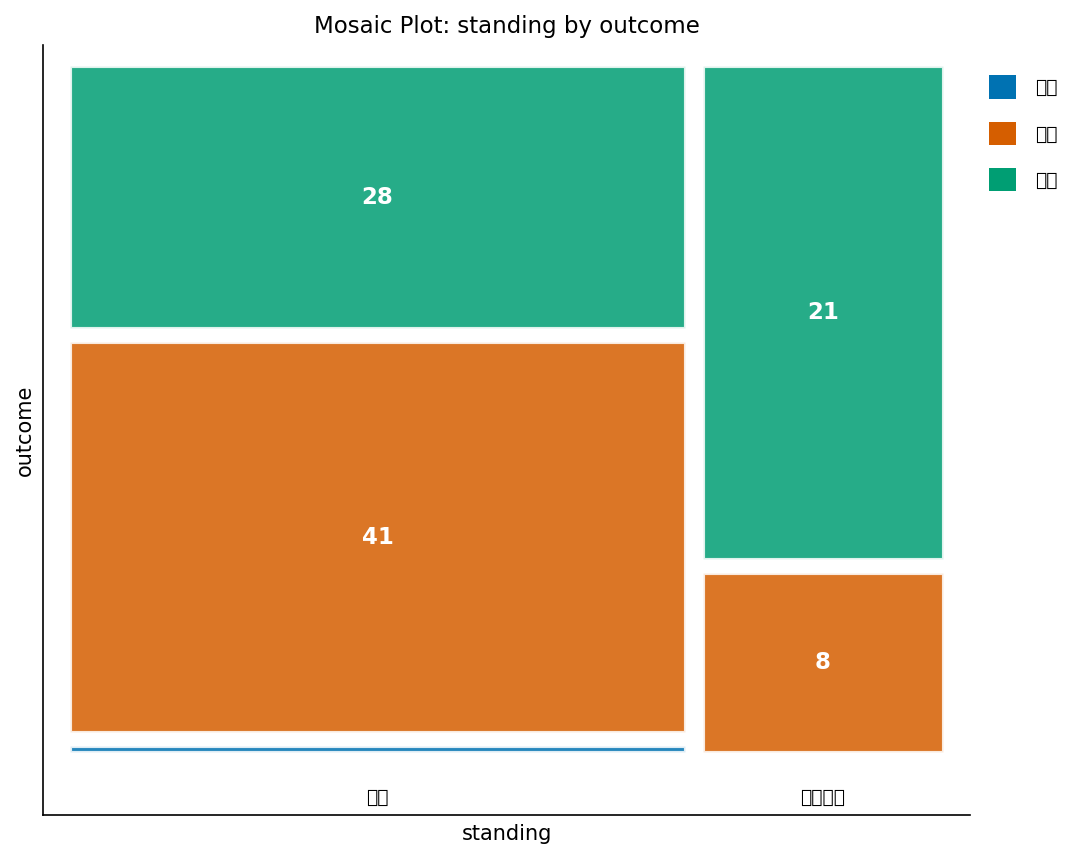

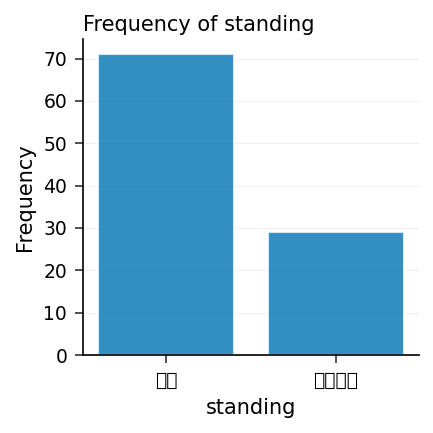

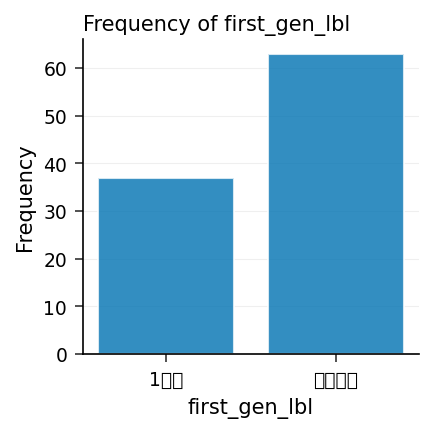

In [3]:
제목 "학사 상태와 학적 결과 교차표";
처리 빈도 데이터=enrollments;
    TABLES standing*outcome / chisq norow nocol nopercent;
    TABLES standing first_gen_lbl;
실행;

## 4. 중퇴는 언제 일어나는가? 상태별 백분위수

실제로 중퇴한 학생들의 경우, *언제* 떠났을까요? **PROC UNIVARIATE**(`dropped = 1`로 제한)는 각 상태 그룹 내 중퇴까지 시간의 10번째, 50번째(중앙값), 90번째 백분위수를 출력 데이터셋에 기록하고 이를 인쇄합니다. 이는 분포를 가정하지 않고 중퇴 타이밍의 산포를 기술합니다.

떠난 학생들 중 중앙값 중퇴는 약 **2.4학기**(학사 경고) 대 **2.6학기**(양호 상태)에서 발생합니다 — 근접한데, 이는 *중퇴를 조건으로 하면* 두 그룹 모두 일찍 떠나는 경향이 있기 때문입니다. 따라서 상태 효과는 주로 중퇴가 *언제* 일어나는지가 아니라 *몇 명이* 중퇴하고 위험군이 얼마나 빨리 얇아지는지에 관한 것이며, 이는 다음 절의 Kaplan-Meier 곡선이 정확히 포착하는 바입니다.

In [4]:
처리 단변량 데이터=enrollments NOPRINT;
    조건 dropped = 1;
    분류 standing;
    변수 time_terms;
    출력 out=drop_ref pctlpts=10 50 90 pctlpre=t_ p=;
실행;

처리 인쇄 데이터=drop_ref noobs 라벨;
    제목 "학사 상태별 중퇴 시점 백분위수(학기)";
    라벨 standing = "학사 상태"
          t_10 = "10 백분위수(학기)"
          t_50 = "중앙값(학기)"
          t_90 = "90 백분위수(학기)";
실행;
제목;

                                                 학사 상태별 중퇴 시점 백분위수(학기)                                                  

        학사 상태              10 백분위수(학기)            중앙값(학기)              90 백분위수(학기)
양호                                 0.4                2.6                      8.7
학사경고                               0.2                2.4                      7.9




NOTE: PROC UNIVARIATE
NOTE: Output dataset drop_ref has 2 observations and 4 variables.
NOTE: PROC PRINT data=drop_ref

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. 학사 상태별 Kaplan-Meier 중퇴 곡선

이제 핵심 생존 단계입니다. **PROC LIFETEST**는 *중퇴까지 시간*에 대한 비모수 **Kaplan-Meier** 생존함수를 추정하며, 졸업과 계속 재학을 절단으로 처리합니다(`dropped(0)`이 절단된 관측치를 표시). `standing`으로 층화하면 그룹당 하나의 중퇴 곡선이 생성되고, `TEST=(LOGRANK WILCOXON)`은 그 곡선들이 다른지에 대한 두 가지 상보적 검정을 수행합니다: **로그순위** 검정은 모든 사건 시점에 동일한 가중치를 두고(후기 차이에 민감), **Wilcoxon** 검정은 초기 사건 시점에 더 큰 가중치를 둡니다(초기 이탈에 민감). `PLOTS=SURVIVAL`은 겹쳐 그린 생존 곡선 그래픽을 요청합니다.

코호트 전체에는 **49건의 중퇴 사건과 51건의 절단** 관측치가 있습니다. 곡선은 뚜렷이 분리됩니다: 학사 경고 학생은 **중앙값 생존(중퇴까지 시간) 3.8학기**에 도달하는 반면, 양호 상태 학생은 두 배 이상 오래 지속됩니다(**8.7학기**). 두 검정 모두 동일성을 기각합니다 — **로그순위 카이제곱 = 10.73, *p* = 0.0011; Wilcoxon 카이제곱 = 7.66, *p* = 0.0056** — 그리고 비교 가능한 통계량은 그 격차가 초기 급증만이 아니라 전체 재학 창에 걸쳐 지속됨을 알려줍니다. 그림은 메시지를 즉각적으로 만듭니다: 주황색 학사 경고 곡선은 처음 네 학기에 걸쳐 가파르게 떨어지는 반면, 파란색 양호 상태 곡선은 높게 유지됩니다.

                                               학사 상태별 Kaplan-Meier 중퇴 곡선                                                

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: 학사 상태 = 양호

                             N
--------------------  --------
Total                       71
Event                       28
Censored                    43
Median Survival Time    8.7000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9859     0.0140              71                 1
  0.2000    0.9718     0.0196              70                 1
  0.4000    0.9577     0.0239              69                 1
  0.5000    0.9437     0.0274              68                 1
  


NOTE: Option TITLE changed to 학사 상태별 Kaplan-Meier 중퇴 곡선.
NOTE: PROC LIFETEST data=enrollments

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


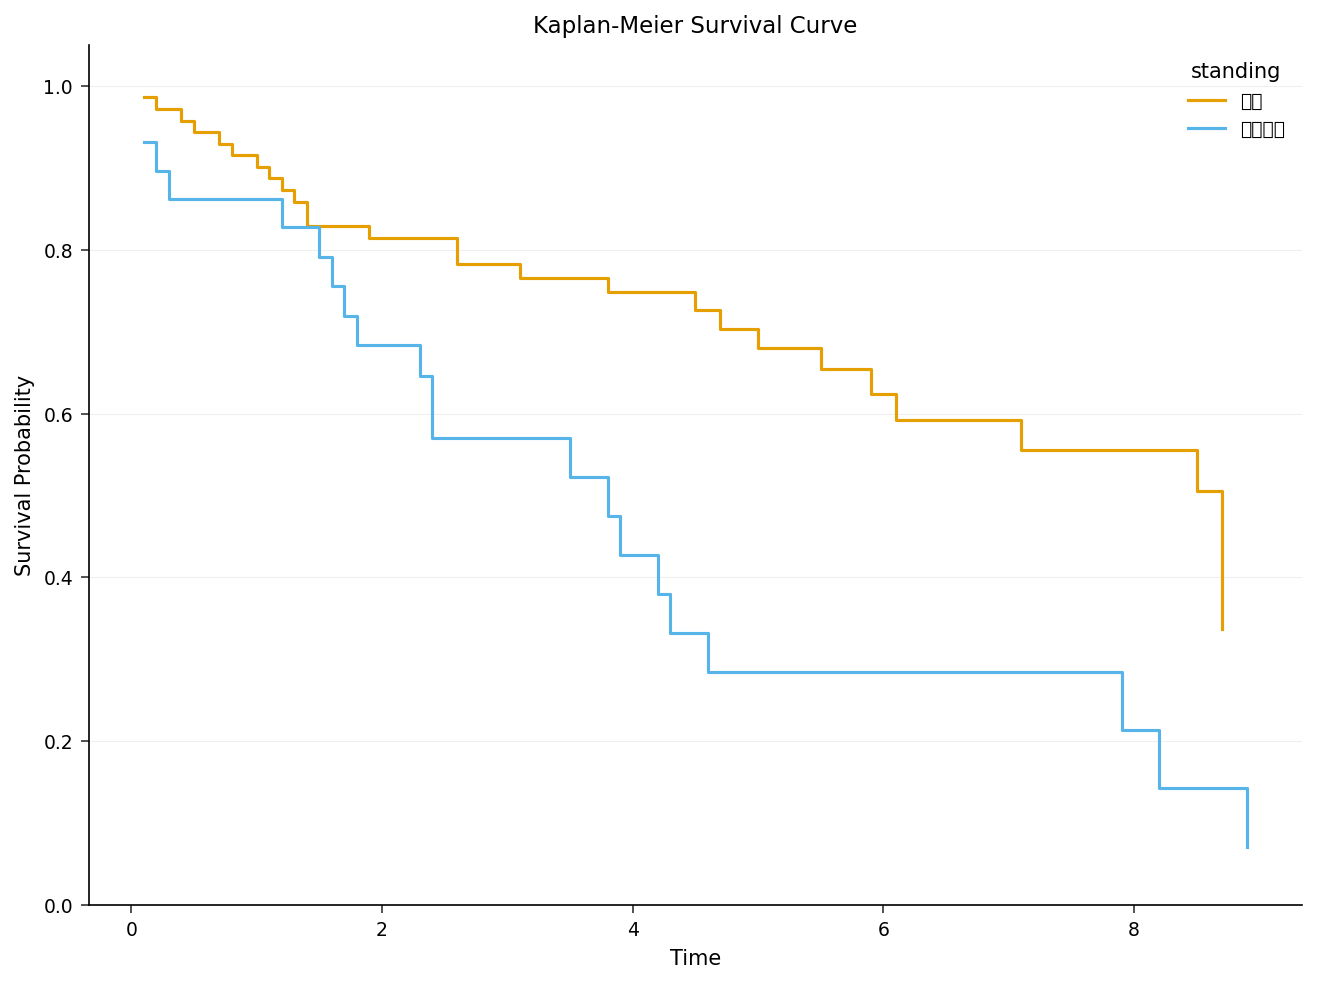

In [5]:
제목 "학사 상태별 Kaplan-Meier 중퇴 곡선";
처리 LIFETEST 데이터=enrollments PLOTS=SURVIVAL METHOD=km;
    TIME time_terms*dropped(0);
    STRATA standing / TEST=(logrank WILCOXON);
실행;
제목;

## 6. 중퇴에 대한 다변량 Cox 비례위험 모델

**PROC PHREG**는 예측변수들을 동시에 보정하여 중퇴 위험에 대한 **Cox 비례위험** 모델을 적합합니다. 주요 요청:

- `dropped(0)`은 **중퇴**를 사건으로 만들고 나머지 모두를 절단으로 만듭니다.
- `CLASS first_gen_lbl (ref="Continuing-gen") / param=ref`는 1세대 요인을 참조 코딩하여 그 위험비가 연속세대 학생 대비 읽히도록 합니다.
- `TIES=EFRON`은 여러 학생이 같은 학기에 떠날 때 권장되는 동점 처리 근사입니다.
- `RL`은 위험비(위험한계) 신뢰구간을 추가합니다.
- `HAZARDRATIO` 문은 참조 그룹 대비 1세대 대조를 보고합니다.

1보다 큰 위험비는 *더 빠른* 중퇴(높은 위험)를 의미하고, 1보다 작으면 *더 느린* 중퇴(보호적)를 의미합니다.

In [6]:
제목 "중퇴에 대한 Cox 비례위험 모델";
처리 PHREG 데이터=enrollments;
    분류 first_gen_lbl (REF="연속세대") / PARAM=REF;
    모형 time_terms*dropped(0) = hs_gpa term1_gpa first_gen_lbl pell
          / TIES=efron rl;
    hazardratio "1세대 대 연속세대" first_gen_lbl / DIFF=REF;
실행;
제목;

                                                   중퇴에 대한 Cox 비례위험 모델                                                   

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                         Analysis of Maximum Likelihood Estimates                                          

Parameter                    DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
---------------------  --------


NOTE: Option TITLE changed to 중퇴에 대한 Cox 비례위험 모델.
NOTE: PROC PHREG data=enrollments

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. 해석 및 다음 단계

**출력을 처음부터 끝까지 읽기:**

- **PROC MEANS**는 시뮬레이션된 신호를 확인합니다: 졸업한 학생은 중퇴한 학생보다 더 높은 첫 학기 GPA(2.94 대 2.54)와 고등학교 GPA(3.10 대 2.90)를 지니며, 여전히 재학 중인 학생들은 12학기 상한에 위치합니다 — 생존 모델이 존중하는 우측 절단입니다.
- **PROC FREQ**는 첫 학기 학사 경고 플래그가 결과를 추적함을 보여주며(표시된 29명 중 21명 중퇴; 양호 상태 71명 중 41명 졸업; *p* = 0.0100), 셀이 희소한 100명 학생 표에서 카이제곱이 취약하다는 점을 정직하게 표시합니다.
- **PROC UNIVARIATE**는 *중퇴를 조건으로 하면* 두 그룹 모두 일찍 떠남을 보여줍니다(중앙값 ~2.4–2.6학기). 상태 효과는 몇 명이 중퇴하고 위험군이 얼마나 빨리 얇아지는지에 관한 것이지, 떠나는 이들 사이의 타이밍에 관한 것이 아닙니다.
- **PROC LIFETEST**는 핵심을 전달합니다: 상태별로 뚜렷이 분리되는 Kaplan-Meier 중퇴 곡선(중앙값 3.8 대 8.7학기; 로그순위 *p* = 0.0011, Wilcoxon *p* = 0.0056). 조기 경보 플래그는 중퇴 타이밍의 진정하고 통계적으로 뒷받침되는 판별자입니다.
- **PROC PHREG**는 각 예측변수의 중퇴 위험에 대한 보정 효과를 정량화합니다. 보정 후, **첫 학기 GPA가 가장 강한 보호 요인**입니다(GPA 1점당 위험비 0.21, 95% CI 0.10–0.44, *p* < 0.0001): 추가되는 GPA 1점마다 중퇴 위험을 대략 5분의 4만큼 줄입니다. **고등학교 GPA**도 보호적입니다(HR 0.45, 95% CI 0.22–0.91, *p* = 0.027). **1세대 학생**은 GPA가 같은 연속세대 동료의 약 두 배 중퇴 위험에 직면합니다(HR 2.03, 95% CI 1.07–3.84, *p* = 0.031). **Pell 지위는 GPA를 통제하면 유의하지 않습니다**(HR 0.95, 95% CI 0.53–1.69, *p* = 0.85) — 원시 위험 요인이 보정 후 사라질 수 있다는 유용한 상기입니다. 전역 귀무가설은 결정적으로 기각됩니다(우도비 카이제곱 = 31.11, 자유도 4, *p* < 0.0001).

**기관은 이를 어떻게 활용할까.** Cox 모델은 코호트를 중퇴 위험으로 순위 매기는 학생별 선형예측자(위험 점수)를 생성합니다. 위험이 가장 높은 학생 — 낮은 첫 학기 GPA와 1세대 지위의 결합 — 은 개입이 가장 저렴하고 효과적인 첫 학기에 조기 경보 상담으로 라우팅됩니다. Kaplan-Meier 비교는 상담자에게 이미 첫 학기 말에 수집하는 단일하고 방어 가능한 기준, 즉 학사 상태를 제공합니다.

**주의사항과 확장.** (1) 이 합성 코호트는 중퇴 모델을 위해 졸업을 절단으로 취급합니다. 실제 데이터에서는 졸업과 중퇴가 진정한 **경쟁 위험**이며, PROC PHREG `EVENTCODE=`를 통한 경쟁 위험(누적 발생률) 확장은 중퇴 확률의 과대 진술을 피할 것입니다. (2) 모든 학기에 걸쳐 단일 위험비를 신뢰하기 전에 비례위험 가정을 점검해야 합니다(PHREG `ASSESS PH` 또는 Schoenfeld 잔차). (3) 시간 가변 공변량 — 학기별 GPA, 재정 지원 변화, 수강 부하 — 은 잔류 데이터에서 흔하며 PHREG 프로그래밍 문으로 자연스럽게 처리됩니다. (4) 여기의 100명 학생 코호트는 라이선스 없는 실행 상한에 맞춰진 것입니다. 운영 분석은 수천 명 학생을 담아 모든 신뢰구간을 조일 것입니다. 배포된 위험 점수는 운영에 활용하기 전에 항상 별도로 보류된 코호트에서 검증하십시오.